# Anomalous User Detection in Recommender Systems
**Approach:** MCA (Multiple Correspondence Analysis) with reconstruction-error anomaly scoring  
**Tracking:** MLflow  
**Primary metric:** AUC (Area Under ROC Curve)

## 1. Setup & Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import entropy as scipy_entropy

import prince
import mlflow

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Global constants ─────────────────────────────────────────────
N_ITEMS      = 1000          # fixed item universe across all weeks
RATING_CATS  = [0,1,2,3,4,5] # possible rating values
NO_INTERACT  = 6             # sentinel category for 'no interaction'

# ── MLflow ─────────────────────────────────────────────────────────
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('Anomaly Detection')
print('Setup complete.')


Setup complete.


## 2. Data Loading

In [20]:
DATA_PATH = 'data/training_batch_with_labels.npz'   # labelled — for training & eval
SCORE_PATH = 'data/first_batch.npz'                 # unlabelled — this week's submission

# ── Load training data (labelled) ────────────────────────────────
data    = np.load(DATA_PATH, allow_pickle=True)
ratings = data['X']
labels  = data['y']

# ── Load scoring data (unlabelled) ───────────────────────────────
score_data    = np.load(SCORE_PATH, allow_pickle=True)
score_ratings = score_data['X']

## 3. EDA

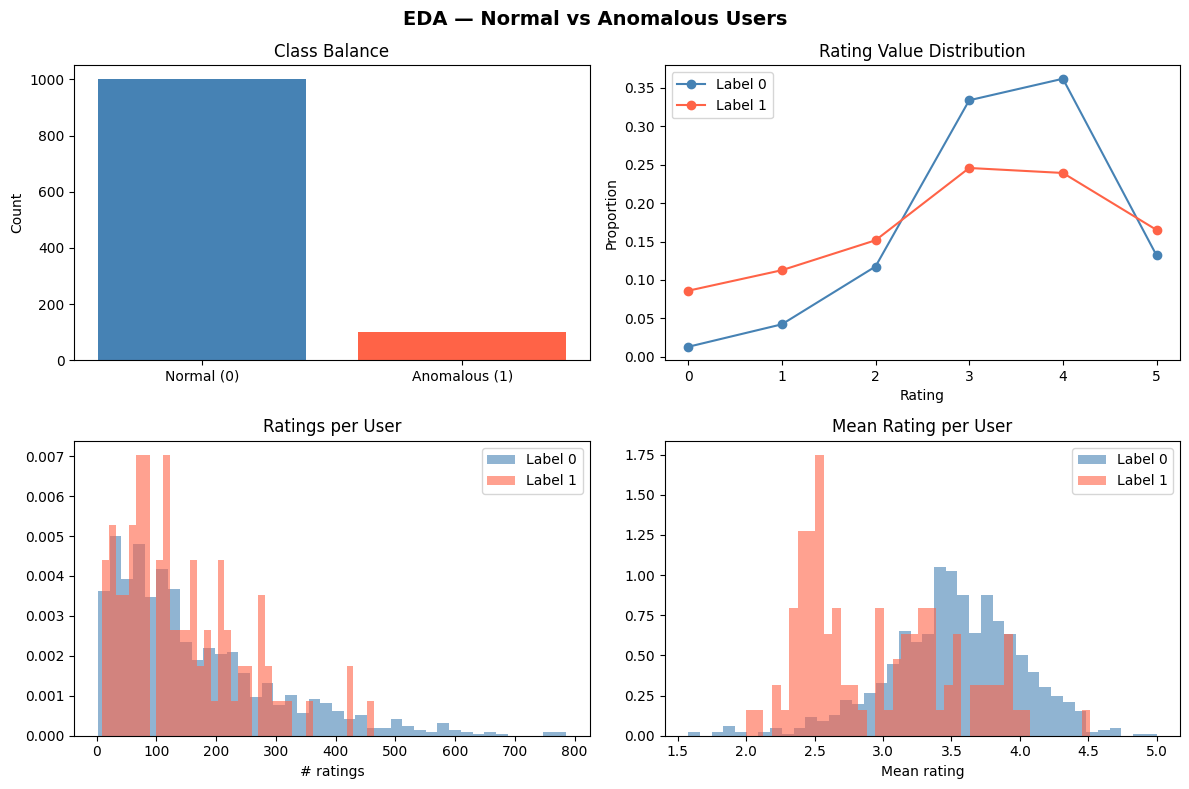

In [ ]:
df_ratings = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])
df_labels  = pd.DataFrame(labels,  columns=['user_id', 'label'])

# Merge so we can split by class
user_activity = (
    df_ratings.groupby('user_id')
    .agg(n_ratings=('rating','count'),
         mean_rating=('rating','mean'),
         std_rating=('rating','std'),
         n_unique_items=('item_id','nunique'))
    .reset_index()
    .merge(df_labels, on='user_id')
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('EDA — Normal vs Anomalous Users', fontsize=14, fontweight='bold')

# Class balance
axes[0,0].bar(['Normal (0)', 'Anomalous (1)'],
               df_labels['label'].value_counts().sort_index(),
               color=['steelblue', 'tomato'])
axes[0,0].set_title('Class Balance')
axes[0,0].set_ylabel('Count')

# Rating value distribution
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    uids = df_labels[df_labels['label']==lbl]['user_id']
    vals = df_ratings[df_ratings['user_id'].isin(uids)]['rating'].value_counts().sort_index()
    axes[0,1].plot(vals.index, vals.values/vals.sum(), marker='o', label=f'Label {lbl}', color=col)
axes[0,1].set_title('Rating Value Distribution')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend()

# Activity: number of ratings
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    sub = user_activity[user_activity['label']==lbl]['n_ratings']
    axes[1,0].hist(sub, bins=40, alpha=0.6, color=col, label=f'Label {lbl}', density=True)
axes[1,0].set_title('Ratings per User')
axes[1,0].set_xlabel('# ratings')
axes[1,0].legend()

# Mean rating per user
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    sub = user_activity[user_activity['label']==lbl]['mean_rating']
    axes[1,1].hist(sub, bins=40, alpha=0.6, color=col, label=f'Label {lbl}', density=True)
axes[1,1].set_title('Mean Rating per User')
axes[1,1].set_xlabel('Mean rating')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('outputs/eda.png', dpi=120)
plt.show()

## 4. Feature Engineering

In [22]:
def build_user_item_matrix(df_ratings, df_labels, n_items=N_ITEMS):
    """
    Returns
    -------
    ui_cat  : pd.DataFrame, shape (n_users, n_items)
              Each cell is a string category: '0','1',...,'5', or 'NI' (no interaction).
              MCA requires categorical / string dtype.
    user_ids: np.array of user IDs (row order)
    """
    user_ids = df_labels['user_id'].values
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}
    n_users = len(user_ids)

    mat = np.full((n_users, n_items), NO_INTERACT, dtype=np.int8)

    for _, row in df_ratings.iterrows():
        u = int(row['user_id'])
        i = int(row['item_id'])
        r = int(row['rating'])
        if u in uid_to_row:
            mat[uid_to_row[u], i] = r

    cat_map = {0:'0', 1:'1', 2:'2', 3:'3', 4:'4', 5:'5', 6:'NI'}
    mat_str = np.vectorize(cat_map.get)(mat)
    ui_cat  = pd.DataFrame(mat_str, columns=[f'item_{i}' for i in range(n_items)])

    return ui_cat, user_ids


# ── Global item popularity (computed once from training data) ────────
_item_popularity = None

def get_item_popularity(df_ratings):
    """Returns a Series: item_id -> popularity rank (1 = most popular)."""
    counts = df_ratings['item_id'].value_counts()
    return counts.rank(ascending=False, method='min')


def build_handcrafted_features(df_ratings, df_labels):
    """
    Extended scalar hand-crafted features per user.

    Feature groups
    --------------
    Volume & coverage
        n_ratings          : total interactions
        n_unique_items     : distinct items rated
        coverage           : n_unique_items / N_ITEMS
        ratings_per_item   : n_ratings / n_unique_items  (>1 flags repeated ratings)

    Rating statistics
        mean_rating        : average star value
        std_rating         : standard deviation of ratings
        rating_var         : variance (0.0 = always same score — suspicious)
        frac_extreme       : proportion of 0- or 5-star ratings
        frac_five          : proportion of 5-star ratings
        frac_zero          : proportion of 0-star ratings
        frac_single_value  : fraction explained by most common rating value
        max_run            : longest consecutive run of same rating (sorted by item_id)

    Information-theoretic
        rating_entropy     : Shannon entropy over rating-value distribution
                             (low entropy -> bot-like uniformity on a few values)
        rating_gini        : Gini coefficient over rating-value counts
                             (high gini -> one value dominates)

    Item-space signals
        mean_item_pop_rank : mean global popularity rank of items rated
                             (low rank = bias to popular items — shill signal)
        std_item_pop_rank  : spread of popularity ranks
        item_id_std        : std of raw item IDs (low = clustered item range)
        item_id_delta_mean : mean gap between consecutive sorted item IDs
        item_id_delta_std  : std of those gaps (low = evenly-spaced grid pattern)
    """
    global _item_popularity
    if _item_popularity is None:
        _item_popularity = get_item_popularity(df_ratings)

    uids = df_labels['user_id'].values
    rows = []

    for uid in uids:
        u_df  = df_ratings[df_ratings['user_id'] == uid]
        r     = u_df['rating'].values.astype(int)
        items = u_df['item_id'].values.astype(int)
        n     = len(r)

        if n == 0:
            rows.append({'user_id': uid})
            continue

        # Volume & coverage
        n_unique         = len(np.unique(items))
        coverage         = n_unique / N_ITEMS
        ratings_per_item = n / max(n_unique, 1)

        # Rating statistics
        mean_r   = r.mean()
        std_r    = r.std()
        var_r    = r.var()
        frac_ext = np.mean((r == 0) | (r == 5))
        frac_5   = np.mean(r == 5)
        frac_0   = np.mean(r == 0)

        val_counts  = np.bincount(r, minlength=6)
        frac_single = val_counts.max() / n

        # Longest run of same rating (sorted by item_id for reproducibility)
        r_sorted = r[np.argsort(items)]
        max_run, cur_run = 1, 1
        for k in range(1, len(r_sorted)):
            if r_sorted[k] == r_sorted[k - 1]:
                cur_run += 1
                max_run  = max(max_run, cur_run)
            else:
                cur_run = 1

        # Information-theoretic
        probs       = val_counts / val_counts.sum()
        rating_ent  = float(scipy_entropy(probs + 1e-9))

        s_counts   = np.sort(val_counts)
        n_cats     = len(s_counts)
        rating_gini = (
            2 * np.sum(np.arange(1, n_cats + 1) * s_counts)
            / (n_cats * s_counts.sum())
            - (n_cats + 1) / n_cats
        )

        # Item-space signals
        default_rank = float(_item_popularity.median())
        mapped_ranks = np.array(
            [_item_popularity.get(it, default_rank) for it in items],
            dtype=float
        )
        mean_pop = mapped_ranks.mean()
        std_pop  = mapped_ranks.std()
        item_std = items.std()

        sorted_items = np.sort(items)
        if len(sorted_items) > 1:
            deltas     = np.diff(sorted_items)
            delta_mean = deltas.mean()
            delta_std  = deltas.std()
        else:
            delta_mean = delta_std = 0.0

        rows.append(dict(
            user_id            = uid,
            n_ratings          = n,
            n_unique_items     = n_unique,
            coverage           = coverage,
            ratings_per_item   = ratings_per_item,
            mean_rating        = mean_r,
            std_rating         = std_r,
            rating_var         = var_r,
            frac_extreme       = frac_ext,
            frac_five          = frac_5,
            frac_zero          = frac_0,
            frac_single_value  = frac_single,
            max_run            = max_run,
            rating_entropy     = rating_ent,
            rating_gini        = rating_gini,
            mean_item_pop_rank = mean_pop,
            std_item_pop_rank  = std_pop,
            item_id_std        = item_std,
            item_id_delta_mean = delta_mean,
            item_id_delta_std  = delta_std,
        ))

    return pd.DataFrame(rows).set_index('user_id').reindex(uids).fillna(0)


print('Building user-item categorical matrix ...')
t0 = time.time()
ui_cat, user_ids = build_user_item_matrix(df_ratings, df_labels)
print(f'  done in {time.time()-t0:.1f}s  shape={ui_cat.shape}')

print('Building hand-crafted features ...')
t1 = time.time()
hc_feats = build_handcrafted_features(df_ratings, df_labels)
print(f'  done in {time.time()-t1:.1f}s  shape={hc_feats.shape}')
print(f'  features: {list(hc_feats.columns)}')

y_true = df_labels.set_index('user_id').reindex(user_ids)['label'].values.astype(int)


Building user-item categorical matrix ...
  done in 4.5s  shape=(1100, 1000)
Building hand-crafted features ...
  done in 1.9s  shape=(1100, 19)
  features: ['n_ratings', 'n_unique_items', 'coverage', 'ratings_per_item', 'mean_rating', 'std_rating', 'rating_var', 'frac_extreme', 'frac_five', 'frac_zero', 'frac_single_value', 'max_run', 'rating_entropy', 'rating_gini', 'mean_item_pop_rank', 'std_item_pop_rank', 'item_id_std', 'item_id_delta_mean', 'item_id_delta_std']


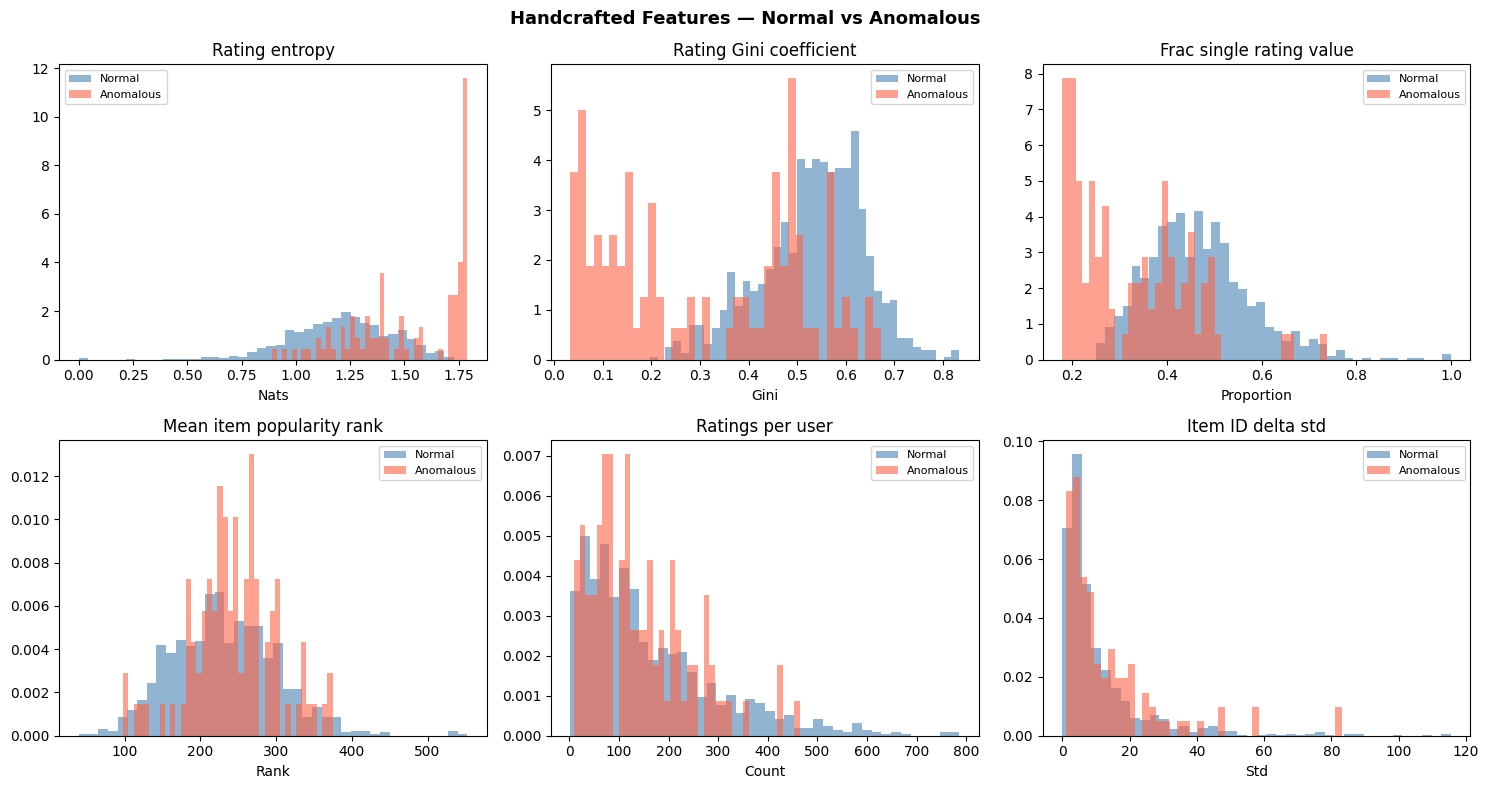

Saved outputs/hc_feature_eda.png


In [23]:
# ── 3b. Handcrafted feature distributions: Normal vs Anomalous ────
key_features = [
    ('rating_entropy',      'Rating entropy',          'Nats'),
    ('rating_gini',         'Rating Gini coefficient', 'Gini'),
    ('frac_single_value',   'Frac single rating value','Proportion'),
    ('mean_item_pop_rank',  'Mean item popularity rank','Rank'),
    ('n_ratings',           'Ratings per user',        'Count'),
    ('item_id_delta_std',   'Item ID delta std',       'Std'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Handcrafted Features — Normal vs Anomalous', fontsize=13, fontweight='bold')

hc_labeled = hc_feats.copy()
hc_labeled['label'] = y_true

for ax, (feat, title, xlabel) in zip(axes.flat, key_features):
    for lbl, col, nm in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Anomalous')]:
        vals = hc_labeled[hc_labeled['label'] == lbl][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=col, label=nm, density=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/hc_feature_eda.png', dpi=120)
plt.show()
print('Saved outputs/hc_feature_eda.png')


## 5. MCA Model

In [24]:
# ── Hyperparameters ────────────────────────────────────────────────
N_COMPONENTS = 1_000      # MCA latent dimensions
SCORE_MODE   = 'reconstruction'  # 'euclidean' | 'mahalanobis' | 'reconstruction'

print(f'Fitting MCA with n_components={N_COMPONENTS} ...')
t0 = time.time()

mca = prince.MCA(
    n_components = N_COMPONENTS,
    n_iter       = 10,
    random_state = SEED,
    engine       = 'sklearn',
)
mca.fit(ui_cat)
train_time = time.time() - t0
print(f'  MCA fitted in {train_time:.1f}s')

t1 = time.time()
embeddings = mca.transform(ui_cat).values   # (n_users, N_COMPONENTS)
infer_time = time.time() - t1
print(f'  Transform done in {infer_time:.1f}s  shape={embeddings.shape}')

print(f'  Explained inertia (cumulative): {mca.cumulative_percentage_of_variance_.data[-1]:.2f}%')
mca.eigenvalues_summary

Fitting MCA with n_components=1000 ...
  MCA fitted in 10.5s
  Transform done in 1.0s  shape=(1100, 1000)
  Explained inertia (cumulative): 99.64%


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.183,3.30%,3.30%
1,0.113,2.04%,5.34%
2,0.086,1.56%,6.90%
3,0.082,1.49%,8.39%
4,0.064,1.15%,9.55%
...,...,...,...
995,0.000,0.01%,99.61%
996,0.000,0.01%,99.62%
997,0.000,0.01%,99.62%


In [25]:
mca.row_contributions_.head().style.format('{:.0%}')

In [26]:
mca.column_contributions_.head().style.format('{:.0%}')

## 6. Anomaly Scoring

In [27]:
def score_euclidean(embeddings):
    """Distance from the MCA origin (centroid)."""
    centroid = embeddings.mean(axis=0, keepdims=True)
    return np.linalg.norm(embeddings - centroid, axis=1)


def score_mahalanobis(embeddings):
    """Mahalanobis distance from the centroid in embedding space."""
    centroid = embeddings.mean(axis=0)
    cov      = np.cov(embeddings.T) + 1e-6 * np.eye(embeddings.shape[1])
    cov_inv  = np.linalg.pinv(cov)
    diff     = embeddings - centroid
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv, diff))


def score_reconstruction(mca, ui_cat):
    """
    Reconstruction error anomaly score.
      1. One-hot encode ui_cat into an indicator matrix
      2. Project to MCA embedding (row coords)
      3. Reconstruct via:  recon = coords @ col_coords.T
      4. Score = per-row Frobenius error
    """
    from sklearn.preprocessing import OneHotEncoder

    enc       = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    indicator = enc.fit_transform(ui_cat)
    coords    = mca.transform(ui_cat).values
    col_coords= mca.column_coordinates(ui_cat).values
    recon     = coords @ col_coords.T
    return np.linalg.norm(indicator.toarray() - recon, axis=1)


def score_isolation_forest(hc_feats_df, contamination=0.05, scaler='robust'):
    """
    Isolation Forest on the extended handcrafted feature vector.
    Returns raw scores where higher = more anomalous.
    """
    X = hc_feats_df.values
    X = (RobustScaler() if scaler == 'robust' else StandardScaler()).fit_transform(X)
    iso = IsolationForest(
        n_estimators  = 300,
        contamination = contamination,
        random_state  = SEED,
        n_jobs        = -1,
    )
    iso.fit(X)
    return -iso.decision_function(X)   # negate: higher = more anomalous


def compute_anomaly_scores(raw_scores):
    """Min-max normalise raw distances to [0, 1]."""
    lo, hi = raw_scores.min(), raw_scores.max()
    return (raw_scores - lo) / (hi - lo + 1e-9)


def score_ensemble(mca_raw, iso_raw, alpha=0.4):
    """
    Weighted combination of MCA and Isolation Forest scores.
    alpha : weight on Isolation Forest  (1-alpha on MCA)
    """
    return alpha * compute_anomaly_scores(iso_raw) + (1 - alpha) * compute_anomaly_scores(mca_raw)


# ── Hyperparameters ─────────────────────────────────────────────────
N_COMPONENTS      = 1_000
SCORE_MODE        = 'reconstruction'  # 'euclidean' | 'mahalanobis' | 'reconstruction'
ENSEMBLE_ALPHA    = 0.4               # weight on IsoForest  (0 = MCA only, 1 = IsoForest only)
ISO_CONTAMINATION = 0.05

# ── MCA ─────────────────────────────────────────────────────────────
print(f'Fitting MCA with n_components={N_COMPONENTS} ...')
t0 = time.time()
mca = prince.MCA(
    n_components = N_COMPONENTS,
    n_iter       = 10,
    random_state = SEED,
    engine       = 'sklearn',
)
mca.fit(ui_cat)
train_time = time.time() - t0
print(f'  MCA fitted in {train_time:.1f}s')

t1 = time.time()
embeddings = mca.transform(ui_cat).values
infer_time = time.time() - t1
print(f'  Transform done in {infer_time:.1f}s  shape={embeddings.shape}')

if SCORE_MODE == 'mahalanobis':
    mca_raw = score_mahalanobis(embeddings)
elif SCORE_MODE == 'euclidean':
    mca_raw = score_euclidean(embeddings)
else:
    mca_raw = score_reconstruction(mca, ui_cat)

# ── Isolation Forest on handcrafted features ─────────────────────
print('Fitting Isolation Forest on handcrafted features ...')
t2 = time.time()
iso_raw = score_isolation_forest(hc_feats, contamination=ISO_CONTAMINATION)
print(f'  done in {time.time()-t2:.1f}s')

# ── Ensemble ────────────────────────────────────────────────────────
anomaly_scores = score_ensemble(mca_raw, iso_raw, alpha=ENSEMBLE_ALPHA)

# ── Evaluation ──────────────────────────────────────────────────────
auc       = roc_auc_score(y_true, anomaly_scores)
threshold = np.percentile(anomaly_scores, 95)
y_pred    = (anomaly_scores >= threshold).astype(int)

prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

auc_mca = roc_auc_score(y_true, compute_anomaly_scores(mca_raw))
auc_iso = roc_auc_score(y_true, compute_anomaly_scores(iso_raw))

print(f'\nAUC (MCA only)          : {auc_mca:.4f}')
print(f'AUC (IsoForest only)    : {auc_iso:.4f}')
print(f'AUC (Ensemble α={ENSEMBLE_ALPHA:.1f})   : {auc:.4f}')
print(f'Precision               : {prec:.4f}')
print(f'Recall                  : {rec:.4f}')
print(f'F1                      : {f1:.4f}')


Fitting MCA with n_components=1000 ...
  MCA fitted in 9.6s
  Transform done in 1.0s  shape=(1100, 1000)
Fitting Isolation Forest on handcrafted features ...
  done in 0.8s

AUC (MCA only)          : 0.6884
AUC (IsoForest only)    : 0.6884
AUC (Ensemble α=0.4)   : 0.6976
Precision               : 0.3636
Recall                  : 0.2000
F1                      : 0.2581


## 7. Evaluation Plots

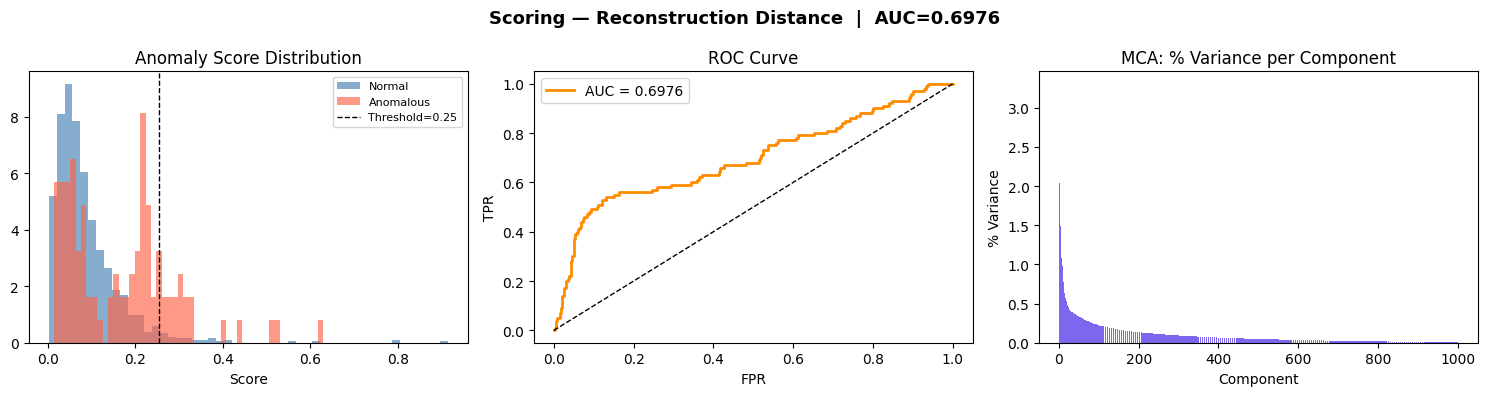

In [28]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Scoring — {SCORE_MODE.capitalize()} Distance  |  AUC={auc:.4f}', fontsize=13, fontweight='bold')

# Score distribution
for lbl, col, nm in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    axes[0].hist(anomaly_scores[y_true==lbl], bins=50, alpha=0.65,
                 color=col, label=nm, density=True)
axes[0].axvline(threshold, color='k', linestyle='--', linewidth=1, label=f'Threshold={threshold:.2f}')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Score')
axes[0].legend(fontsize=8)

# ROC curve
fpr, tpr, _ = roc_curve(y_true, anomaly_scores)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Explained inertia per component
inertia = mca.percentage_of_variance_
axes[2].bar(range(1, len(inertia)+1), inertia, color='mediumslateblue')
axes[2].set_title('MCA: % Variance per Component')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('% Variance')

plt.tight_layout()
plt.savefig('outputs/evaluation.png', dpi=120)
plt.show()

## 8. Analysis — t-SNE, Ablation & Failure Cases

Running t-SNE on MCA embeddings (this may take a minute) ...


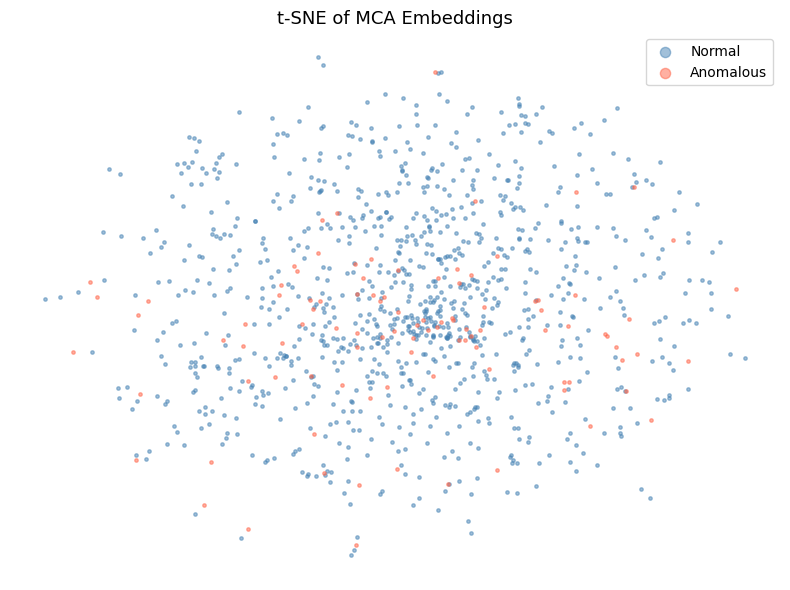

In [29]:
# ── 8a. t-SNE visualisation of MCA embeddings ─────────────────────
print('Running t-SNE on MCA embeddings (this may take a minute) ...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, col, nm in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    mask = y_true == lbl
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               c=col, s=6, alpha=0.5, label=nm)
ax.set_title('t-SNE of MCA Embeddings', fontsize=13)
ax.legend(markerscale=3)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/tsne.png', dpi=120)
plt.show()

=== Axis 1: MCA scoring mode vs n_components ===
  mahalanobis      n_comp=   2  AUC=0.5732
  mahalanobis      n_comp=   5  AUC=0.5208
  mahalanobis      n_comp=  10  AUC=0.5276
  mahalanobis      n_comp=  50  AUC=0.5924
  mahalanobis      n_comp= 100  AUC=0.6184
  mahalanobis      n_comp= 300  AUC=0.6556
  mahalanobis      n_comp= 500  AUC=0.6690
  mahalanobis      n_comp= 750  AUC=0.6877
  mahalanobis      n_comp=1000  AUC=0.6950
  reconstruction   n_comp=   2  AUC=0.5548
  reconstruction   n_comp=   5  AUC=0.5566
  reconstruction   n_comp=  10  AUC=0.5410
  reconstruction   n_comp=  50  AUC=0.6101
  reconstruction   n_comp= 100  AUC=0.6377
  reconstruction   n_comp= 300  AUC=0.6790
  reconstruction   n_comp= 500  AUC=0.6837
  reconstruction   n_comp= 750  AUC=0.6877
  reconstruction   n_comp=1000  AUC=0.6884

=== Axis 2: Ensemble alpha sweep ===
  alpha=0.0  AUC=0.6884
  alpha=0.1  AUC=0.7037
  alpha=0.2  AUC=0.7023
  alpha=0.3  AUC=0.6997
  alpha=0.4  AUC=0.6976
  alpha=0.5  AUC=0.

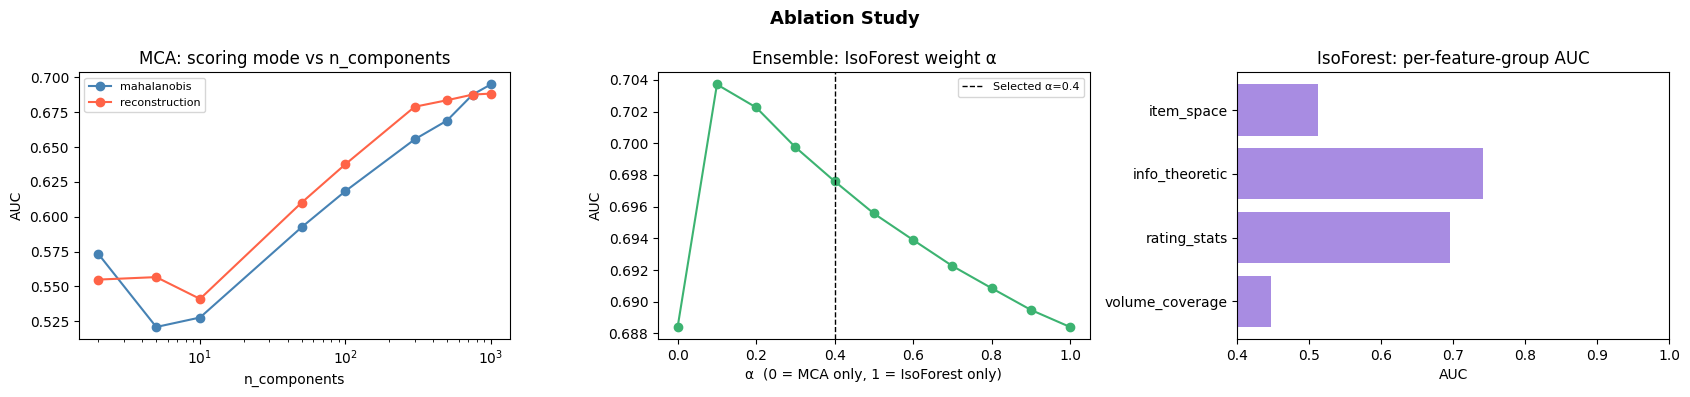

In [30]:
# ── 8b. Extended Ablation Study ─────────────────────────────────
# Three axes:
#   1. MCA scoring mode × n_components
#   2. Ensemble alpha sweep
#   3. Feature-group contribution (individual + cumulative)

ablation_results = []

# ── Axis 1: MCA mode vs n_components ────────────────────────────
print('=== Axis 1: MCA scoring mode vs n_components ===')
for mode in ['mahalanobis', 'reconstruction']:
    for n_comp in [2, 5, 10, 50, 100, 300, 500, 750, 1000]:
        _mca = prince.MCA(n_components=n_comp, n_iter=5, random_state=SEED, engine='sklearn')
        _mca.fit(ui_cat)
        _emb = _mca.transform(ui_cat).values
        raw  = score_mahalanobis(_emb) if mode == 'mahalanobis' else score_reconstruction(_mca, ui_cat)
        auc_ = roc_auc_score(y_true, compute_anomaly_scores(raw))
        ablation_results.append({'axis': 'mca_mode', 'mode': mode,
                                  'n_components': n_comp, 'alpha': None, 'auc': auc_})
        print(f'  {mode:15s}  n_comp={n_comp:4d}  AUC={auc_:.4f}')

# ── Axis 2: Ensemble alpha sweep ────────────────────────────────
print('\n=== Axis 2: Ensemble alpha sweep ===')
for alpha_ in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    s    = score_ensemble(mca_raw, iso_raw, alpha=alpha_)
    auc_ = roc_auc_score(y_true, s)
    ablation_results.append({'axis': 'alpha', 'mode': SCORE_MODE,
                              'n_components': N_COMPONENTS, 'alpha': alpha_, 'auc': auc_})
    print(f'  alpha={alpha_:.1f}  AUC={auc_:.4f}')

# ── Axis 3: Feature-group contribution ──────────────────────────
print('\n=== Axis 3: Feature-group contribution ===')
feature_groups = {
    'volume_coverage' : ['n_ratings', 'n_unique_items', 'coverage', 'ratings_per_item'],
    'rating_stats'    : ['mean_rating', 'std_rating', 'rating_var', 'frac_extreme',
                         'frac_five', 'frac_zero', 'frac_single_value', 'max_run'],
    'info_theoretic'  : ['rating_entropy', 'rating_gini'],
    'item_space'      : ['mean_item_pop_rank', 'std_item_pop_rank',
                         'item_id_std', 'item_id_delta_mean', 'item_id_delta_std'],
}

for group_name, cols in feature_groups.items():
    raw_ = score_isolation_forest(hc_feats[cols], contamination=ISO_CONTAMINATION)
    auc_ = roc_auc_score(y_true, compute_anomaly_scores(raw_))
    ablation_results.append({'axis': 'feature_group', 'mode': group_name,
                              'n_components': None, 'alpha': None, 'auc': auc_})
    print(f'  IsoForest [{group_name:18s}]  AUC={auc_:.4f}')

# Cumulative feature addition
cumulative_cols = []
for group_name, cols in feature_groups.items():
    cumulative_cols += cols
    raw_ = score_isolation_forest(hc_feats[cumulative_cols], contamination=ISO_CONTAMINATION)
    auc_ = roc_auc_score(y_true, compute_anomaly_scores(raw_))
    ablation_results.append({'axis': 'cumulative', 'mode': group_name,
                              'n_components': len(cumulative_cols), 'alpha': None, 'auc': auc_})
    print(f'  Cumulative +{group_name:18s}  ({len(cumulative_cols):2d} feats)  AUC={auc_:.4f}')

df_ablation = pd.DataFrame(ablation_results)

# ── Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Ablation Study', fontsize=13, fontweight='bold')

for mode, col in [('mahalanobis', 'steelblue'), ('reconstruction', 'tomato')]:
    sub = df_ablation[(df_ablation['axis']=='mca_mode') & (df_ablation['mode']==mode)]
    axes[0].plot(sub['n_components'], sub['auc'], marker='o', label=mode, color=col)
axes[0].set_title('MCA: scoring mode vs n_components')
axes[0].set_xlabel('n_components'); axes[0].set_ylabel('AUC')
axes[0].legend(fontsize=8); axes[0].set_xscale('log')

sub2 = df_ablation[df_ablation['axis']=='alpha'].sort_values('alpha')
axes[1].plot(sub2['alpha'], sub2['auc'], marker='o', color='mediumseagreen')
axes[1].axvline(ENSEMBLE_ALPHA, color='k', linestyle='--', linewidth=1,
                label=f'Selected α={ENSEMBLE_ALPHA}')
axes[1].set_title('Ensemble: IsoForest weight α')
axes[1].set_xlabel('α  (0 = MCA only, 1 = IsoForest only)')
axes[1].set_ylabel('AUC'); axes[1].legend(fontsize=8)

sub3 = df_ablation[df_ablation['axis']=='feature_group']
axes[2].barh(sub3['mode'], sub3['auc'], color='mediumpurple', alpha=0.8)
axes[2].set_title('IsoForest: per-feature-group AUC')
axes[2].set_xlabel('AUC'); axes[2].set_xlim(0.4, 1.0)

plt.tight_layout()
plt.savefig('outputs/ablation.png', dpi=120)
plt.show()


True Positives (detected anomalies): 20
False Negatives (missed anomalies) : 80
False Positives (wrongly flagged)  : 35


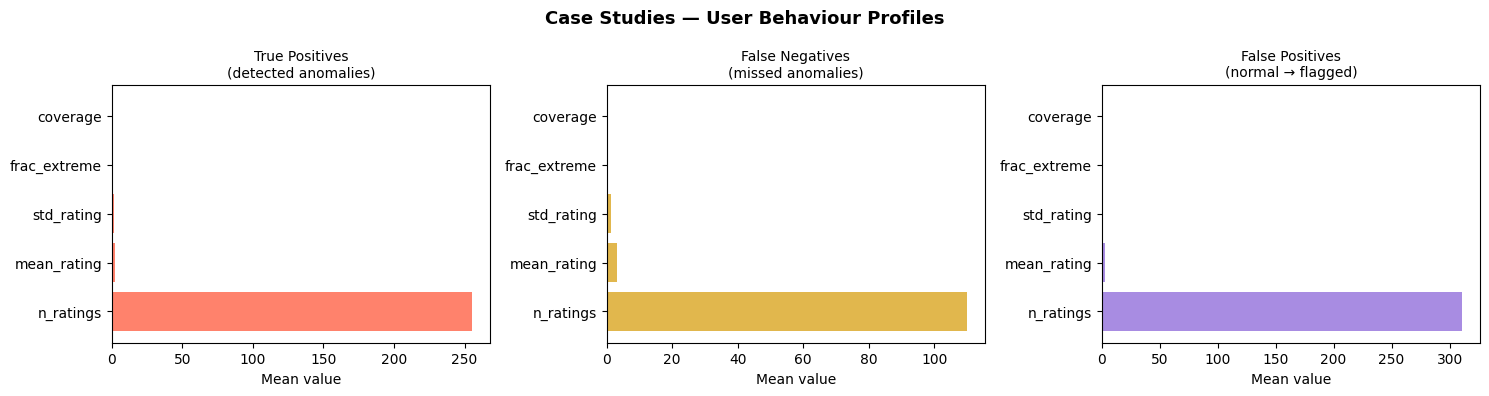

In [31]:
# ── 8c. Case studies — correct detections & failure cases ─────────

df_results = pd.DataFrame({
    'user_id'      : user_ids,
    'label'        : y_true,
    'score'        : anomaly_scores,
    'pred'         : y_pred,
    'correct'      : (y_true == y_pred).astype(int),
}).set_index('user_id').join(hc_feats)

# True positives (correctly detected anomalies)
tp = df_results[(df_results['label']==1) & (df_results['pred']==1)]
# False negatives (missed anomalies)
fn = df_results[(df_results['label']==1) & (df_results['pred']==0)]
# False positives (normal users flagged)
fp = df_results[(df_results['label']==0) & (df_results['pred']==1)]

print(f'True Positives (detected anomalies): {len(tp)}')
print(f'False Negatives (missed anomalies) : {len(fn)}')
print(f'False Positives (wrongly flagged)  : {len(fp)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Case Studies — User Behaviour Profiles', fontsize=13, fontweight='bold')

for ax, subset, title, col in zip(axes,
                                   [tp, fn, fp],
                                   ['True Positives\n(detected anomalies)',
                                    'False Negatives\n(missed anomalies)',
                                    'False Positives\n(normal → flagged)'],
                                   ['tomato','goldenrod','mediumpurple']):
    if len(subset) == 0:
        ax.text(0.5, 0.5, 'None', ha='center', va='center')
        ax.set_title(title)
        continue
    feats = ['n_ratings','mean_rating','std_rating','frac_extreme','coverage']
    means = subset[feats].mean()
    ax.barh(feats, means, color=col, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean value')

plt.tight_layout()
plt.savefig('outputs/case_studies.png', dpi=120)
plt.show()

In [32]:
# ── 8d. Computational cost analysis ───────────────────────────────

n_users = len(user_ids)
cost_summary = {
    'n_users'           : n_users,
    'n_interactions'    : len(df_ratings),
    'mca_train_time_s'  : round(train_time, 2),
    'mca_infer_time_s'  : round(infer_time, 2),
    'ms_per_user_infer' : round(infer_time / n_users * 1000, 3),
}
print('Computational cost summary:')
for k, v in cost_summary.items():
    print(f'  {k:<25s}: {v}')

Computational cost summary:
  n_users                  : 1100
  n_interactions           : 177346
  mca_train_time_s         : 9.58
  mca_infer_time_s         : 1.0
  ms_per_user_infer        : 0.911


## 9. MLflow Logging

In [33]:
with mlflow.start_run(run_name=f'mca-ensemble-{SCORE_MODE}-{N_COMPONENTS}comp'):

    mlflow.log_params({
        'n_components'      : N_COMPONENTS,
        'score_mode'        : SCORE_MODE,
        'ensemble_alpha'    : ENSEMBLE_ALPHA,
        'iso_contamination' : ISO_CONTAMINATION,
        'n_hc_features'     : hc_feats.shape[1],
        'threshold_pct'     : 95,
        'seed'              : SEED,
        'data_path'         : DATA_PATH,
    })

    mlflow.log_metrics({
        'auc'           : auc,
        'auc_mca_only'  : auc_mca,
        'auc_iso_only'  : auc_iso,
        'precision'     : prec,
        'recall'        : rec,
        'f1'            : f1,
        'train_time_s'  : train_time,
        'infer_time_s'  : infer_time,
        'n_users'       : len(user_ids),
        'n_interactions': len(df_ratings),
    })

    for artifact in ['outputs/eda.png', 'outputs/hc_feature_eda.png',
                     'outputs/evaluation.png', 'outputs/tsne.png',
                     'outputs/ablation.png', 'outputs/case_studies.png',
                     'outputs/submission.npz']:
        mlflow.log_artifact(artifact)

print(f'MLflow run logged.')
print(f'  AUC (MCA only)       = {auc_mca:.4f}')
print(f'  AUC (IsoForest only) = {auc_iso:.4f}')
print(f'  AUC (Ensemble)       = {auc:.4f}')


🏃 View run mca-ensemble-reconstruction-1000comp at: http://localhost:5000/#/experiments/2/runs/123c0655f1e544b3a4ac2d150fe5eb17
🧪 View experiment at: http://localhost:5000/#/experiments/2
MLflow run logged.
  AUC (MCA only)       = 0.6884
  AUC (IsoForest only) = 0.6884
  AUC (Ensemble)       = 0.6976


## 10. Output — Save Submission

In [ ]:
# Build matrix and features for unlabelled users
df_score_ratings = pd.DataFrame(score_ratings, columns=['user_id', 'item_id', 'rating'])

score_user_ids   = np.unique(score_ratings[:, 0].astype(int))
df_score_labels  = pd.DataFrame({'user_id': score_user_ids, 'label': -1})

ui_cat_score, score_user_ids_ordered = build_user_item_matrix(df_score_ratings, df_score_labels)

# Handcrafted features — _item_popularity reused from training (no leakage)
hc_feats_score = build_handcrafted_features(df_score_ratings, df_score_labels)

# MCA: transform with already-fitted model — do NOT refit
score_embeddings = mca.transform(ui_cat_score).values
if SCORE_MODE == 'mahalanobis':
    score_mca_raw = score_mahalanobis(score_embeddings)
elif SCORE_MODE == 'euclidean':
    score_mca_raw = score_euclidean(score_embeddings)
else:
    score_mca_raw = score_reconstruction(mca, ui_cat_score)

# IsoForest: re-use training item popularity; score on unlabelled features
score_iso_raw = score_isolation_forest(hc_feats_score, contamination=ISO_CONTAMINATION)

# Ensemble
submission_scores = score_ensemble(score_mca_raw, score_iso_raw, alpha=ENSEMBLE_ALPHA)

np.savez('outputs/submission.npz',
         user_ids=score_user_ids_ordered,
         scores=submission_scores)

print(f'Submission saved: {len(score_user_ids_ordered)} users')
print(f'Score range: [{submission_scores.min():.4f}, {submission_scores.max():.4f}]')


ValueError: operands could not be broadcast together with shapes (1100,6409) (1100,6705) 

: 